In [118]:
import os
import sys
import numpy as np
import swyft
import pickle
import matplotlib.pyplot as plt
import torch
import importlib
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor
torch.set_float32_matmul_precision('medium')
device_notebook = "cuda" if torch.cuda.is_available() else "cpu"
import wandb
import copy
from torch.multiprocessing import Pool
torch.multiprocessing.set_start_method('spawn',force=True)
torch.set_num_threads(28)
import itertools
import subprocess
from tqdm.auto import tqdm
sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
from explim_functions import generate_expected_limits
from scipy.integrate import trapz

In [3]:
main_dir = "ALPs_with_SWYFT"
thesis_figs = os.getcwd().split(main_dir)[0]+"/"+main_dir+"/thesis_figures/"

In [4]:
names = [
    'flare2_agnostic', 'flare2_semi_informed', 'flare2_informed','flare2_confident1',
    'flare3_agnostic', 'flare3_semi_informed', 'flare3_informed','flare3_confident1',
]
titles = ["Agnostic Prior", "Semi-Informed Prior", "Informed Prior", "Confident Prior", "CTAO Prior'"]
ALP_titles = {"flare0":"ALP-O","flare1":"ALP-A","flare2":"ALP-B","flare3":"ALP-C",}
xlabel = "ALP mass ($m_\mathrm{a}$) / $\mathrm{neV}$"
ylabel = "Photon-ALP coupling ($g_{\mathrm{a}\gamma}$) / $10^{-11} \ \mathrm{GeV}^{-1}$"
colors_priors = ['r','#FFA500','y','g','b', ]

In [5]:
priors = {}
for ip, name in enumerate(names):

    priors[name] = {'name': name}

    priors[name]['results_path'] = '/home/gertwk/ALPs_with_SWYFT/cluster_runs/analysis_results/'+name

    priors[name]['store_path'] = priors[name]['results_path']+"/sim_output/store"

    priors[name]['config_vars'] = priors[name]['results_path'] +'/config_variables.pickle'

    priors[name]['config_phys'] = priors[name]['results_path'] +'/physics_variables.pickle'
    
    priors[name]['truncation_record'] = priors[name]['results_path'] +'/truncation_record.pickle'

    removed_ALP_sim=0
    try:
        sys.path.remove('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')
        removed_ALP_sim=1
    except ValueError:
        pass
    try:
        del sys.modules['ALP_quick_sim']
    except KeyError:
        pass
    try:
        del sys.modules['alp_swyft_simulator']
    except KeyError:
        pass
    sys.path.append(priors[name]['results_path'])
    import param_function
    import ALP_quick_sim
    import alp_swyft_simulator 
    ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator
    with open(priors[name]['config_vars'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['config_phys'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    with open(priors[name]['truncation_record'], 'rb') as file: config_objects = pickle.load(file)
    for key in config_objects.keys(): priors[name][key] = config_objects[key]
    sys.path.remove(priors[name]['results_path'])
    sys.path.append(priors[name]['results_path']+'/train_output/net')
    import network
    sys.path.remove(priors[name]['results_path']+'/train_output/net')
    
    count = 0
    for combo in itertools.product(*priors[name]['hyperparams'].values()):
        if count == priors[name]['which_grid_point']:
            hyperparams_point = {}
            for i, key in enumerate(priors[name]['hyperparams'].keys()):
                hyperparams_point[key]=combo[i]
        count +=1
        
    priors[name]['net_path'] = (priors[name]['results_path'] + '/train_output/net/trained_network_round_'
                                +str(priors[name]['which_truncation'])+'_gridpoint_'+str(priors[name]['which_grid_point'])+'.pt')

    priors[name]['net'] = network.NetworkCorner(nbins=priors[name]['A'].nbins, marginals=priors[name]['POI_indices'], 
                                                param_names=priors[name]['A'].param_names, **hyperparams_point)

    priors[name]['net'].load_state_dict(torch.load(priors[name]['net_path']))

    bad_params_bounds = copy.copy(priors[name]['bounds_rounds'][0][-2])
    A = copy.deepcopy(priors[name]['A'])
    bad_params_bounds[0] = [-1,-1]
    bad_params_bounds[1] = [-1,-1]
    priors[name]['bad_params_bounds'] = copy.copy(bad_params_bounds)
    priors[name]['bad_params_sim'] = ALP_SWYFT_Simulator(A, bad_params_bounds, priors[name]['prior_funcs'])

    # with open(priors[name]['results_path']+'/explim_predictions.pickle', 'rb') as file:
    #     priors[name]['predictions'] = pickle.load(file)
    
    if priors[name]['which_truncation'] > 0:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_bad_params = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_bad_params_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior_round_"+str(priors[name]['which_truncation'])+"_gridpoint_"+str(priors[name]['which_grid_point']))
    else:
        store_explim = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_explim")
        store_bad_params = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_bad_params")
        store_prior = swyft.ZarrStore(priors[name]['store_path'] + "/" + priors[name]['store_name']+"_prior")
    priors[name]['samples_explim'] = store_explim.get_sample_store()
    priors[name]['samples_prior'] = store_prior.get_sample_store()
    try:
        priors[name]['samples_bad_params'] = store_bad_params.get_sample_store()
    except:
        sands = priors[name]['bad_params_sim'].get_shapes_and_dtypes()
        store_bad_params.init(
            N = 200,
            chunk_size = 200,
            shapes=sands[0],
            dtypes=sands[1],
        )
        store_bad_params.simulate(priors[name]['bad_params_sim'],batch_size = 200)
        priors[name]['samples_bad_params'] = store_bad_params.get_sample_store()
 
    del sys.modules['param_function']
    del sys.modules['ALP_quick_sim']
    del sys.modules['alp_swyft_simulator']
    del sys.modules['network']
    if not '/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim' in sys.path: 
        sys.path.append('/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim')

import alp_swyft_simulator 
ALP_SWYFT_Simulator = alp_swyft_simulator.ALP_SWYFT_Simulator


/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packag

In [6]:
trainer = swyft.SwyftTrainer(accelerator = 'cuda', precision = 64,logger=False,)

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [7]:
contour_matrices = {}
exclusion_areas = {}

In [8]:
sys.path

['/home/gertwk/ALPs_with_SWYFT/notebooks/thesis_results/expected_limits/posterior_comparisons',
 '/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python39.zip',
 '/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9',
 '/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/lib-dynload',
 '',
 '/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages',
 '/tmp/tmporos6a36',
 '/home/gertwk/ALPs_with_SWYFT/analysis_scripts/ALP_sim']

In [9]:
# del sys.modules['explim_functions']
# from explim_functions import generate_expected_limits

In [10]:
colors=['b','g','y','#FFA500','r','k']
line_colors=['b','g','#FFA500','r','b']
linestyles = [':','-.','--','-','-']

In [11]:
def find_sorted_position(index,array):
    sorted_indices = np.argsort(array)
    index_position = np.empty_like(sorted_indices)
    index_position[sorted_indices] = np.arange(len(array))
    return str(int(np.round(100*index_position[index]/len(array),decimals=0))) + '%'

In [12]:
for n in range(17):
    print(find_sorted_position(6,priors[name]['samples_bad_params']['params'][spec_selection][:,n]))

NameError: name 'spec_selection' is not defined

In [13]:
len(spec_selection)

NameError: name 'spec_selection' is not defined

In [14]:
priors[name]['samples_bad_params']['params'][spec_selection][6]

NameError: name 'spec_selection' is not defined

In [91]:
priors[name]['samples_bad_params']['params'][spec_selection][:,5]

array([ 67.0538  , 123.592674, 118.28389 ,  83.94399 ,  75.7163  ,
       131.08691 ,  40.84876 , 121.04822 , 110.23127 , 139.64926 ,
       140.23636 , 137.4524  , 114.58866 , 103.617516,  68.963745,
       130.21216 , 151.46812 , 155.41734 ,  72.63078 , 117.14618 ,
       102.97924 , 158.89197 ,  95.38481 ,  71.17224 ,  88.250854,
       133.11925 , 116.473404], dtype=float32)

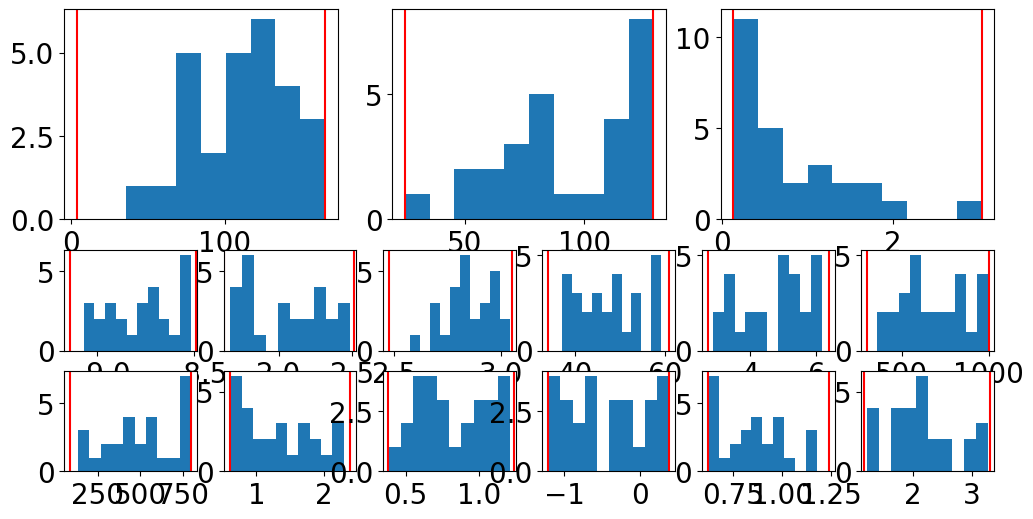

In [133]:
spec_selection = [5,16,22,23,43,48,62,70,72,84,86,103,113,123,125,129,134,136,146,148,158,161,162,164,172,186,191]
fig_dist = plt.figure(figsize=(12,6))
for i, p in enumerate([5,9,13]):
    fig_dist.add_subplot(2,3,i+1)
    lower_bound = priors[name]['bounds_rounds'][0][-2][p][0]
    upper_bound = priors[name]['bounds_rounds'][0][-2][p][1]
    plt.hist(priors[name]['samples_bad_params']['params'][spec_selection][:,p], range=(lower_bound,upper_bound))
    plt.axvline(lower_bound, color='r')
    plt.axvline(upper_bound, color='r')
for i, p in enumerate([2,3,4,6,7,8,10,11,12,14,15,16]):
    fig_dist.add_subplot(4,6,12+i+1)
    plt.hist(priors[name]['samples_bad_params']['params'][spec_selection][:,p])
    plt.axvline(priors[name]['bounds_rounds'][0][-2][p][0], color='r')
    plt.axvline(priors[name]['bounds_rounds'][0][-2][p][1], color='r')

In [140]:
labels[2]

'Cut-Off Energy ($E_{cut}$) / GeV'

/tmp/ipykernel_591375/4012901063.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  fig_dist.axes[i].set_yticklabels(fig_dist.axes[i].get_yticklabels(),fontsize=15)


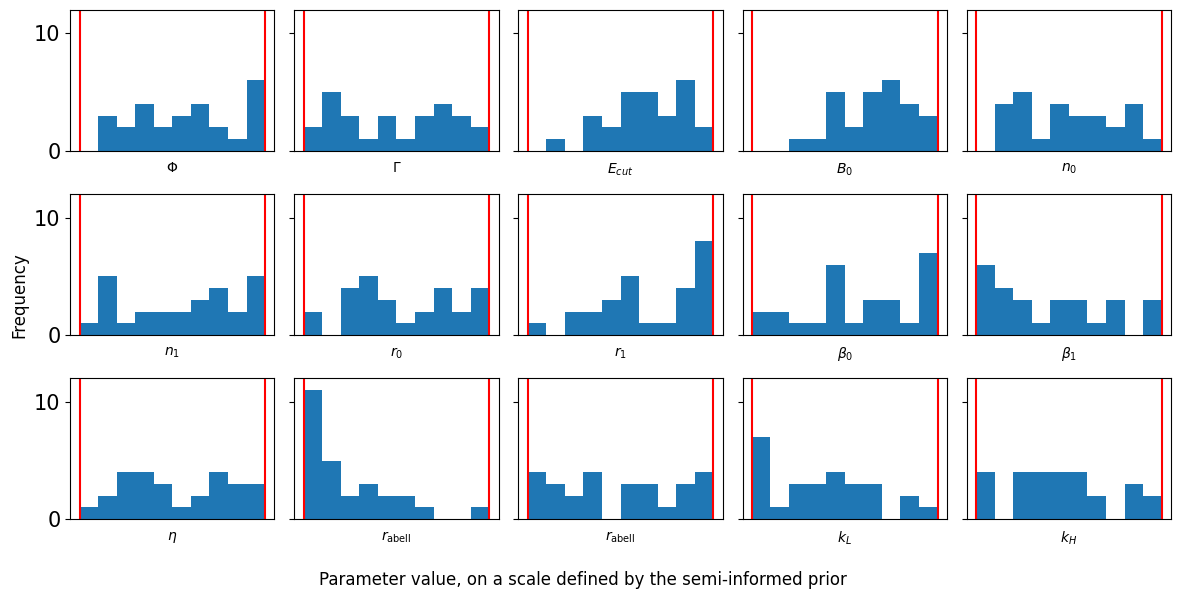

In [168]:
labels = [
    "ALP mass ($m_\mathrm{a}$) / $\mathrm{neV}$",
    "Photon-ALP coupling ($g_{\mathrm{a}\gamma}$) / $10^{-11} \mathrm{GeV}^{-1}$",
    "$\Phi$",
    "$\Gamma$",
    "$E_{cut}$",
    "$B_0$",
    "$n_0$",
    "$n_1$",
    "$r_0$",
    "$r_1$",
    "$\\beta_0$",
    "$\\beta_1$",
    "$\\eta$",
    "$r_\mathrm{abell}$",
    "$r_\mathrm{abell}$",
    "$k_L$",
    "$k_H$",
    "$q$",
]


spec_selection = [5,16,22,23,43,48,62,70,72,84,86,103,113,123,125,129,134,136,146,148,158,161,162,164,172,186,191]
fig_dist = plt.figure(figsize=(12,6))
for i, p in enumerate(np.arange(2,17)):
    fig_dist.add_subplot(3,5,i+1)
    lower_bound = priors[name]['bounds_rounds'][0][-2][p][0]
    upper_bound = priors[name]['bounds_rounds'][0][-2][p][1]
    plt.hist(priors[name]['samples_bad_params']['params'][spec_selection][:,p], range=(lower_bound,upper_bound))
    plt.axvline(lower_bound, color='r')
    plt.axvline(upper_bound, color='r')
    plt.xlabel(labels[p])
    plt.xticks([])
    plt.ylim([0,12])
    if i not in [0,5,10]:
        fig_dist.axes[i].set_yticklabels([])
    else:
        fig_dist.axes[i].set_yticklabels(fig_dist.axes[i].get_yticklabels(),fontsize=15)

fig_dist.supxlabel('Parameter value, on a scale defined by the semi-informed prior ')
fig_dist.supylabel('Frequency')

fig_dist.tight_layout()

Text(0.5, 0, 'dfss')

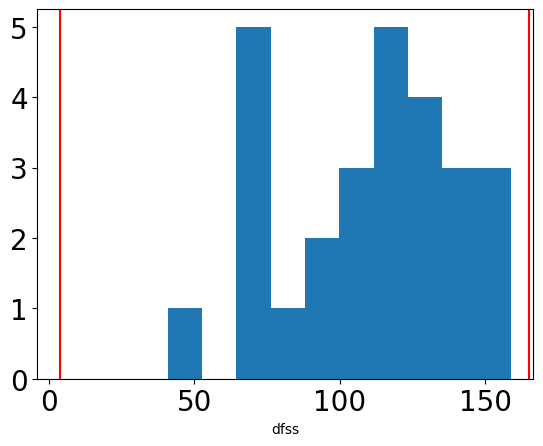

In [138]:
n = 5
spec_selection = [5,16,22,23,43,48,62,70,72,84,86,103,113,123,125,129,134,136,146,148,158,161,162,164,172,186,191]
plt.hist(
    priors[name]['samples_bad_params']['params'][spec_selection][:,n]
)
plt.axvline(priors[name]['bounds_rounds'][0][-2][n][0], color='r')
plt.axvline(priors[name]['bounds_rounds'][0][-2][n][1], color='r')
plt.xlabel('dfss')

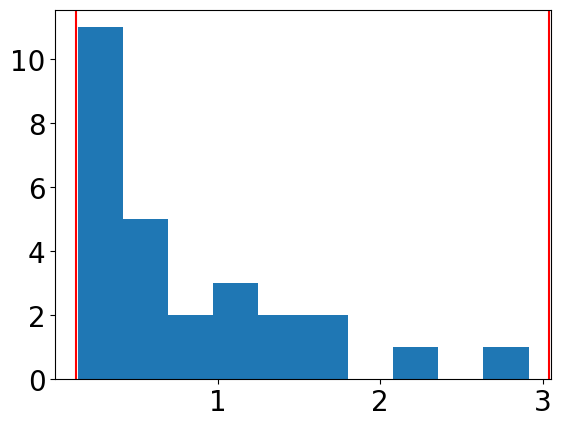

In [87]:
n = 13
spec_selection = [5,16,22,23,43,48,62,70,72,84,86,103,113,123,125,129,134,136,146,148,158,161,162,164,172,186,191]
plt.hist(
    priors[name]['samples_bad_params']['params'][spec_selection][:,n]
)
plt.axvline(priors[name]['bounds_rounds'][0][-2][n][0], color='r')
plt.axvline(priors[name]['bounds_rounds'][0][-2][n][1], color='r')

#9, 13?

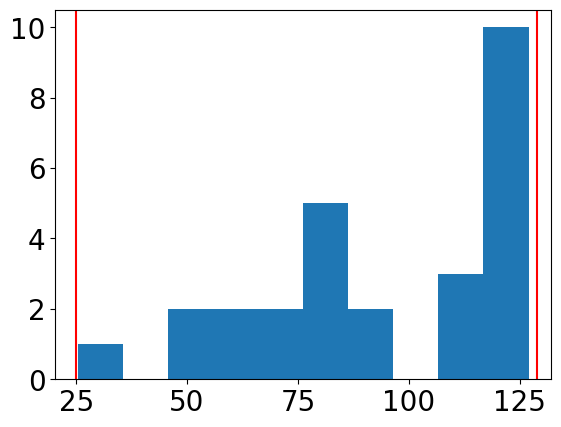

In [89]:
n = 9
spec_selection = [5,16,22,23,43,48,62,70,72,84,86,103,113,123,125,129,134,136,146,148,158,161,162,164,172,186,191]
plt.hist(
    priors[name]['samples_bad_params']['params'][spec_selection][:,n]
)
plt.axvline(priors[name]['bounds_rounds'][0][-2][n][0], color='r')
plt.axvline(priors[name]['bounds_rounds'][0][-2][n][1], color='r')

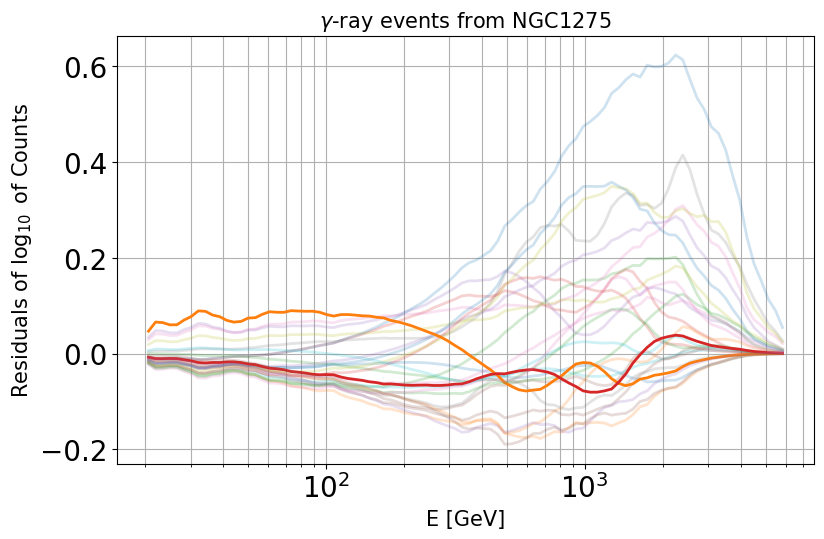

In [117]:
name = 'flare2_semi_informed'

A = priors[name]['A']

samples = priors[name]['samples_bad_params']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for j,i in enumerate([5,16,22,23,43,48,62,70,72,84,86,103,113,123,125,129,134,136,146,148,158,161,162,164,172,186,191]):#range(min(len(samples),10)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if j==0 else 0
    transparency = 0.79 if i not in [161,164] else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=1,plot_obs=0, transparency=transparency)

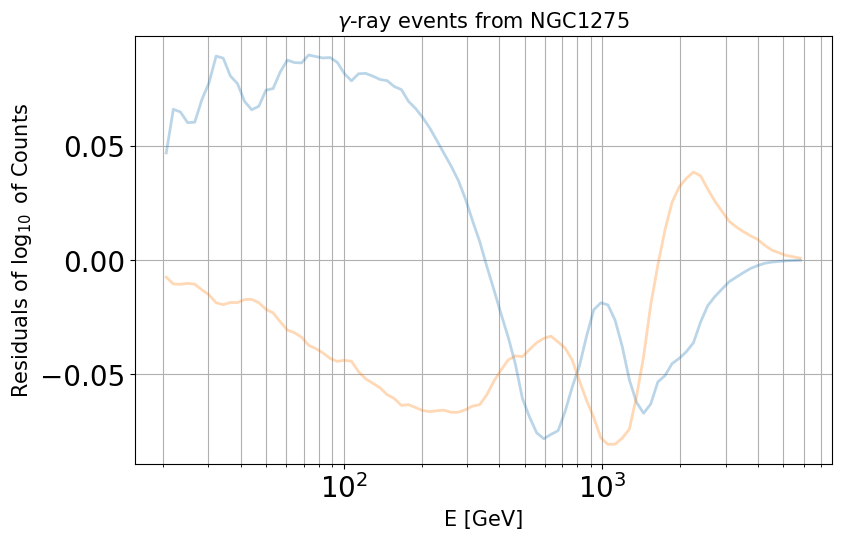

In [16]:
name = 'flare2_semi_informed'

A = priors[name]['A']

samples = priors[name]['samples_bad_params']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for j,i in enumerate([161, 164]):#range(min(len(samples),10)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if j==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=1,plot_obs=0, transparency=0.7)

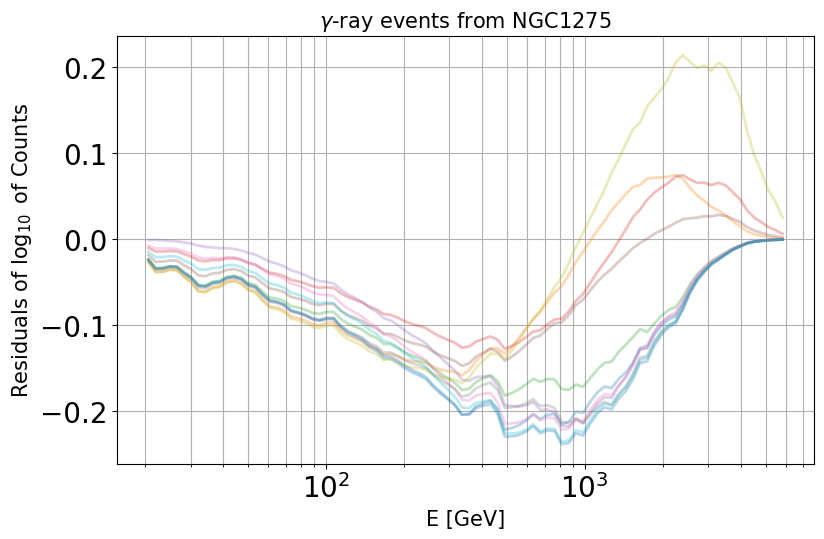

In [17]:
name = 'flare2_semi_informed'

A = priors[name]['A']

samples = priors[name]['samples_bad_params']

A.configure_plot(xmin=None, xmax=None, ymin=None,ymax=None,legend=0, logx=1, logy=0)
for j,i in enumerate([30, 58, 68, 87, 94, 99, 115, 127, 141, 176, 183]):#range(min(len(samples),10)):
    A.configure_model(params=samples[i]['params'])
    A.import_counts(obs=samples[i]['data'],exp=samples[i]['exp'])
    new_fig = 1 if j==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=None,color_obs=None,linestyle="-",
                   label_exp=0,label_obs=False, errorbands=False, errors=False, plot_exp=1,plot_obs=0, transparency=0.7)

In [18]:
def prepare_logratios(name, data):
    logratios = []
    for spectrum in data:
        lrs = trainer.infer(
            priors[name]['net'],
            spectrum,
            priors[name]['samples_prior'],
        )
        logratios.append(lrs)
    return logratios

def plot_posteriors(name,logratios,data,figsize=None, axes=None, colors_truth='r',linestyles_truth ='--',POIs=[0,1]):
    fig = None
    if axes is None:
        if figsize is None: figsize = (12,12/len(logratios))
        fig = plt.figure(figsize=figsize)
        for j in range(len(logratios)): fig.add_subplot(1,len(logratios),j+1)
        axes = fig.axes
    A = priors[name]['A']
    if not isinstance(colors_truth,list):
        one_color = copy.copy(colors_truth)
        colors_truth = [one_color]*len(logratios)
    if not isinstance(linestyles_truth,list):
        one_linestyle = copy.copy(linestyles_truth)
        linestyles_truth = [one_linestyle]*len(logratios)
    for j in range(len(logratios)):
        swyft.plot.plot._plot_2d(
            logratios[j],
            A.param_names[POIs[0]],
            A.param_names[POIs[1]],
            color='k',
            # color_truth=colors_truth[j],
            # linestyle_truth = linestyles_truth[j],
            smooth=3,
            truth=None, #{A.param_names[i]:data[j]['params'][i] for i in POIs},
            ax = axes[j]
        )
        axes[j].axvline(data[j]['params'][POIs[0]], color=colors_truth[j], lw=2.0, zorder=10, ls=linestyles_truth[j])
        axes[j].axhline(data[j]['params'][POIs[1]], color=colors_truth[j], lw=2.0, zorder=10, ls=linestyles_truth[j])
    return fig
    

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/pytorch_lightning/loops/epoch/prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

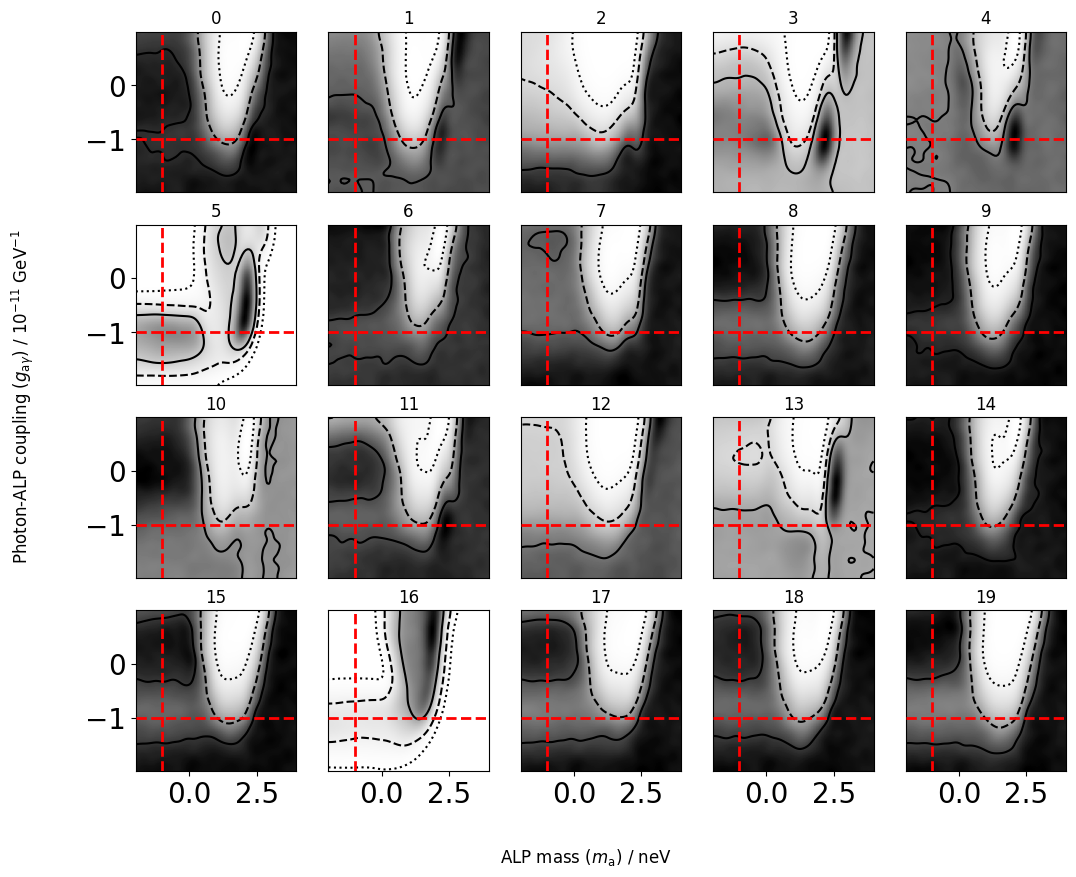

In [19]:
name = 'flare2_semi_informed'
n = 20
data = [priors[name]['samples_bad_params'][i] for i in range(n)]

dim = 5
fig = plt.figure(figsize=(12,(12/dim)*np.ceil(n/dim)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(len(data)/dim)),dim,i+1)
    fig.axes[-1].set_title(str(i))
    if i < n-dim:
        fig.axes[-1].set_xticks([])
    # else:
    #     fig.axes[-1].set_xticks([ms[i-(len(gs)-1)*(dim)]])
    if i%dim != 0:
        fig.axes[-1].set_yticks([])
    # else:
    #     fig.axes[-1].set_yticks([gs[int(i/dim)]])
fig.supxlabel(xlabel)
fig.supylabel(ylabel)


logratios = prepare_logratios(name,data)
plot_posteriors(name, logratios, data, axes = fig.axes)

In [88]:
priors[name]['bounds_rounds'][0][-2][1][0]

-1.999993920326233

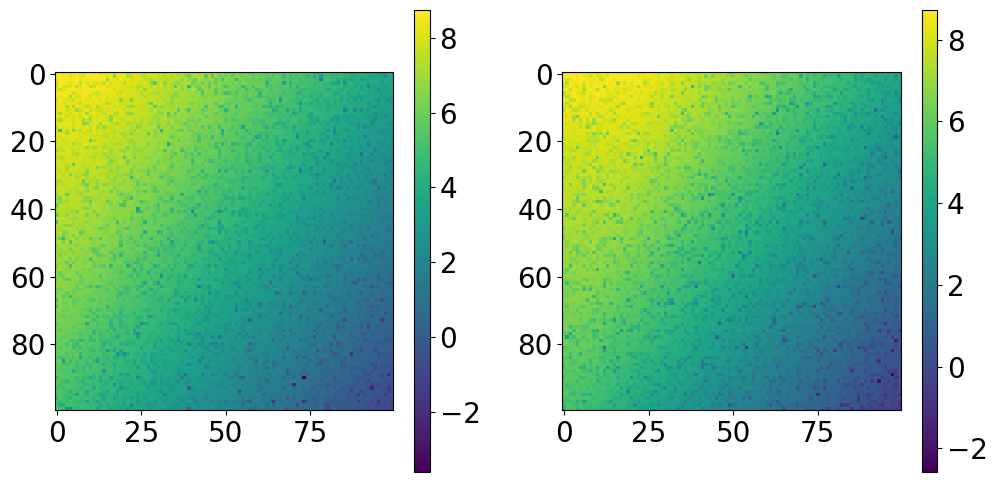

In [89]:
n = 100

B = 25
s = 300_000 #pc
Egamma1 = 100
Egamma2 = 1000

ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
gs = np.logspace(priors[name]['bounds_rounds'][0][-2][1][0],priors[name]['bounds_rounds'][0][-2][1][1],n)[::-1]
m, g = np.meshgrid(ms,gs)

ms = ms/1_000
Egamma1 = Egamma1/1000
Egamma2 = Egamma2/1000
B_GeV = B*1.95e-20
s = s*3.0857e+18/1.98e-14

gbs = s*g*1e-11*B_GeV
Ecrit = 247*(m**2)*(10/(B*g))
sqrt1 = np.sqrt(1+(Ecrit/Egamma1))
sqrt2 = np.sqrt(1+(Ecrit/Egamma2))

d1 = -(0.25*gbs/sqrt1)*np.sin(gbs*sqrt1)
d2 = -(0.25*gbs/sqrt2)*np.sin(gbs*sqrt2)

fig = plt.figure(figsize=(12, 6))
fig.add_subplot(1,2,1)
fig.add_subplot(1,2,2)
fig.axes[0].imshow(np.log10(abs(d1)))
fig.axes[1].imshow(np.log10(abs(d2)))
cbar0 = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], aspect=30)
cbar1 = fig.colorbar(fig.axes[1].get_images()[0],ax=fig.axes[1], aspect=30)

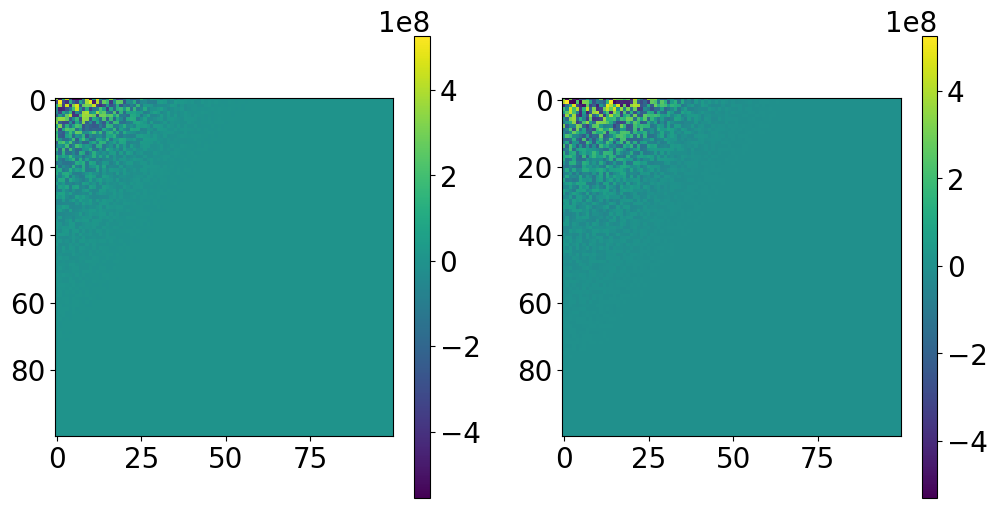

In [94]:
n = 100

B = 25
s = 300_000 #pc
Egamma1 = 100
Egamma2 = 1000

ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
gs = np.logspace(priors[name]['bounds_rounds'][0][-2][1][0],priors[name]['bounds_rounds'][0][-2][1][1],n)[::-1]
m, g = np.meshgrid(ms,gs)

ms = ms/1_000
Egamma1 = Egamma1/1000
Egamma2 = Egamma2/1000
B_GeV = B*1.95e-20
s = s*3.0857e+18/1.98e-14

gbs = s*g*1e-11*B_GeV
Ecrit = 247*(m**2)*(10/(B*g))
sqrt1 = np.sqrt(1+(Ecrit/Egamma1))
sqrt2 = np.sqrt(1+(Ecrit/Egamma2))

d1 = -(0.25*gbs/sqrt1)*np.sin(gbs*sqrt1)
d2 = -(0.25*gbs/sqrt2)*np.sin(gbs*sqrt2)

fig = plt.figure(figsize=(12, 6))
fig.add_subplot(1,2,1)
fig.add_subplot(1,2,2)
fig.axes[0].imshow(d1)
fig.axes[1].imshow(d2)
cbar0 = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], aspect=30)
cbar1 = fig.colorbar(fig.axes[1].get_images()[0],ax=fig.axes[1], aspect=30)

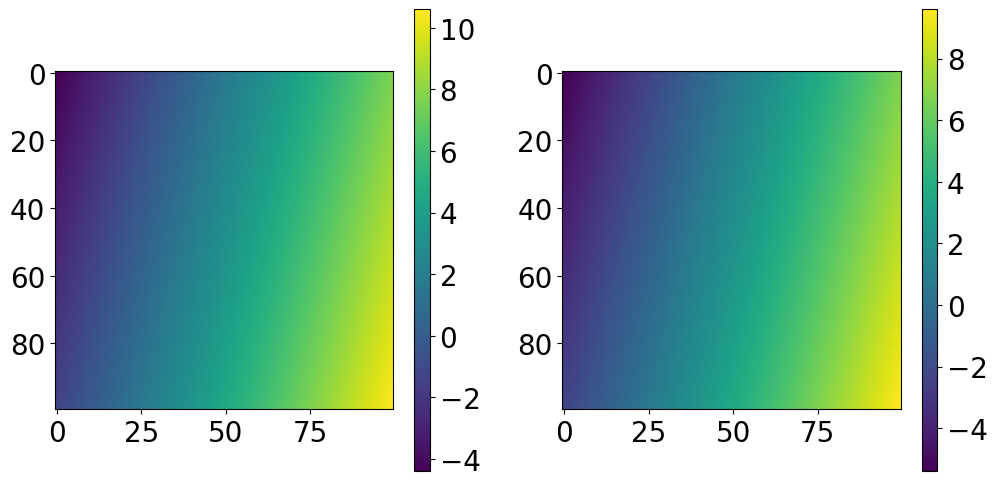

In [82]:
n = 100

B = 25
s = 0.01 #pc
Egamma1 = 100
Egamma2 = 1000

ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
gs = np.logspace(priors[name]['bounds_rounds'][0][-2][1][0],priors[name]['bounds_rounds'][0][-2][1][1],n)[::-1]
m, g = np.meshgrid(ms,gs)

ms = ms/1_000
Egamma1 = Egamma1/1000
Egamma2 = Egamma2/1000
B_GeV = B*1.95e-20
s = s*3.0857e+18/1.98e-14

gbs = s*g*1e-11*B_GeV
Ecrit = 247*(m**2)*(10/(B*g))
sqrt1 = np.sqrt(1+(Ecrit/Egamma1))
sqrt2 = np.sqrt(1+(Ecrit/Egamma2))

d1 = -(0.25*gbs/sqrt1)*np.sin(gbs*sqrt1)
d2 = -(0.25*gbs/sqrt2)*np.sin(gbs*sqrt2)

fig = plt.figure(figsize=(12, 6))
fig.add_subplot(1,2,1)
fig.add_subplot(1,2,2)
fig.axes[0].imshow(np.log10(Ecrit/Egamma1))
fig.axes[1].imshow(np.log10(Ecrit))
cbar0 = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], aspect=30)
cbar1 = fig.colorbar(fig.axes[1].get_images()[0],ax=fig.axes[1], aspect=30)

In [68]:
ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
ms

array([1.00000357e-02, 1.14976089e-02, 1.32194539e-02, 1.51991568e-02,
       1.74753338e-02, 2.00923836e-02, 2.31013545e-02, 2.65609391e-02,
       3.05386200e-02, 3.51119857e-02, 4.03702439e-02, 4.64159619e-02,
       5.33670673e-02, 6.13591479e-02, 7.05480968e-02, 8.11131532e-02,
       9.32603986e-02, 1.07226776e-01, 1.23284714e-01, 1.41747437e-01,
       1.62975078e-01, 1.87381702e-01, 2.15443384e-01, 2.47707493e-01,
       2.84803371e-01, 3.27454609e-01, 3.76493160e-01, 4.32875566e-01,
       4.97701621e-01, 5.72235817e-01, 6.57932015e-01, 7.56461801e-01,
       8.69747090e-01, 9.99997621e-01, 1.14975405e+00, 1.32193753e+00,
       1.51990665e+00, 1.74752298e+00, 2.00922641e+00, 2.31012171e+00,
       2.65607811e+00, 3.05384384e+00, 3.51117769e+00, 4.03700038e+00,
       4.64156859e+00, 5.33667499e+00, 6.13587830e+00, 7.05476773e+00,
       8.11126708e+00, 9.32598439e+00, 1.07226139e+01, 1.23283981e+01,
       1.41746594e+01, 1.62974108e+01, 1.87380587e+01, 2.15442102e+01,
      

In [67]:
priors[name]['bounds_rounds'][0][-2][0][1]

3.9999938011169434

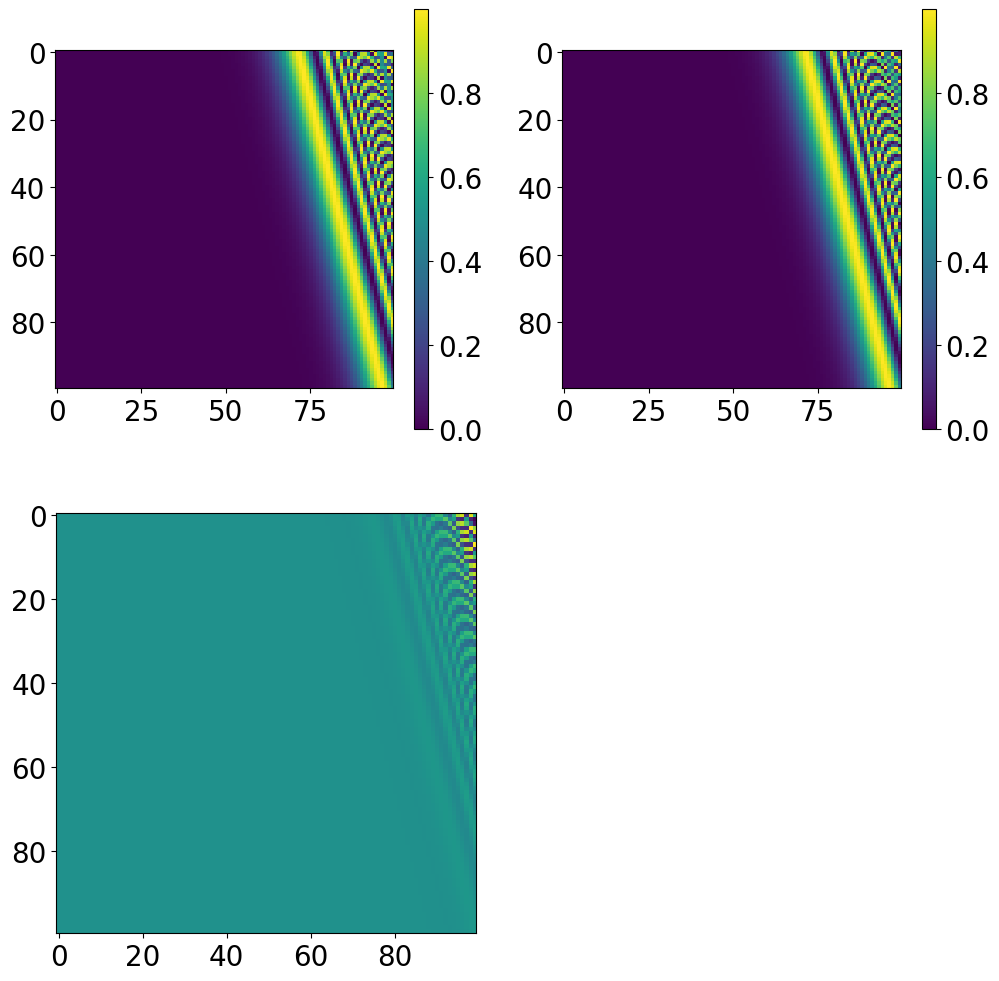

In [110]:
n = 100

B = 25
s = 0.2 #pc
Egamma1 = 100
Egamma2 = 101

ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
gs = np.logspace(priors[name]['bounds_rounds'][0][-2][1][0],priors[name]['bounds_rounds'][0][-2][1][1],n)[::-1]
m, g = np.meshgrid(ms,gs)

ms = ms/1_000
Egamma1 = Egamma1/1000
Egamma2 = Egamma2/1000
B_GeV = B*1e-6*1.95e-20
s = s*3.0857e+18/1.98e-14

Ecrit = 247*(m**2)*(10/(B*g))
arg1 = 0.5*s*g*1e-11*B_GeV*np.sqrt(1 + Ecrit/Egamma1)
arg2 = 0.5*s*g*1e-11*B_GeV*np.sqrt(1 + Ecrit/Egamma2)

fig = plt.figure(figsize=(12, 12))
fig.add_subplot(2,2,1)
fig.add_subplot(2,2,2)
fig.add_subplot(2,2,3)
fig.axes[0].imshow(np.sin(arg1)**2)
fig.axes[1].imshow(np.sin(arg2)**2)
fig.axes[2].imshow(np.sin(arg2)**2-np.sin(arg1)**2)
# fig.axes[1].imshow(np.sin(arg2)**2-np.sin(arg1)**2)
cbar0 = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], aspect=30)
cbar1 = fig.colorbar(fig.axes[1].get_images()[0],ax=fig.axes[1], aspect=30)

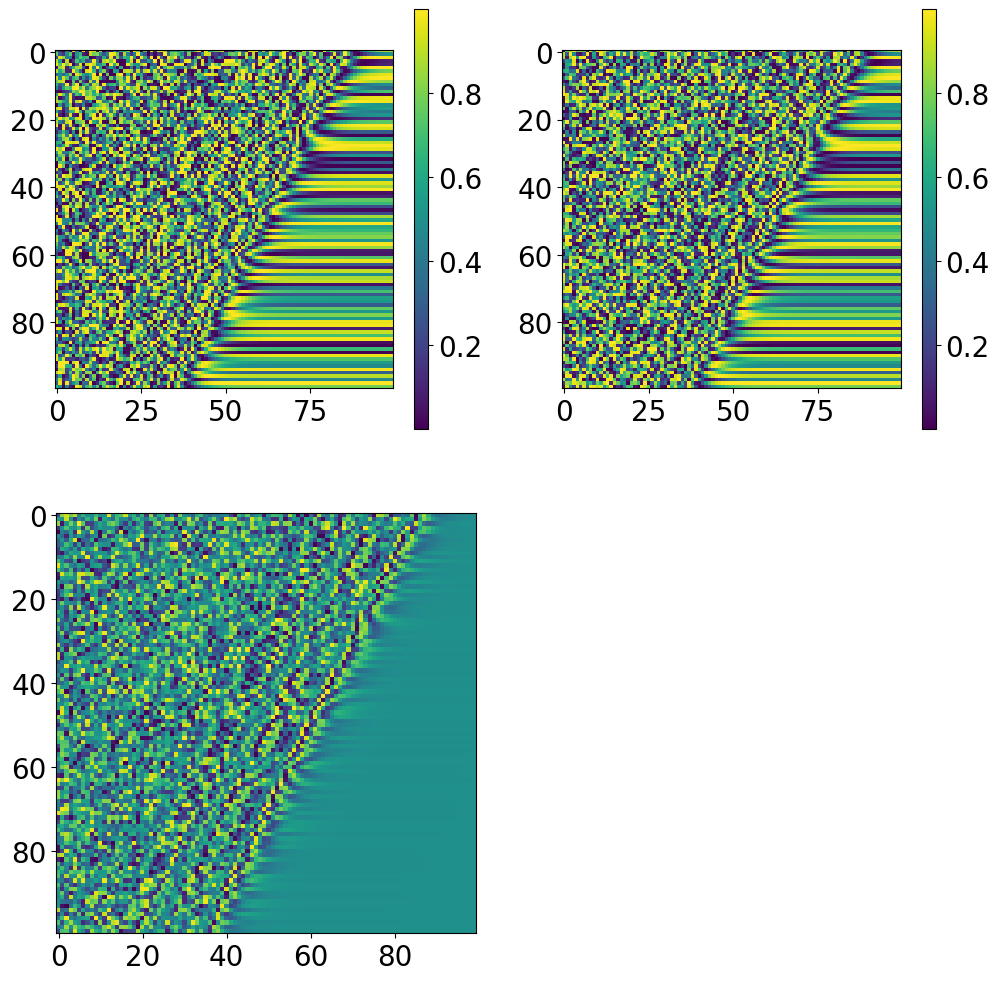

In [111]:
n = 100

B = 25
s = 300_000 #pc
Egamma1 = 100
Egamma2 = 150

ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
gs = np.logspace(priors[name]['bounds_rounds'][0][-2][1][0],priors[name]['bounds_rounds'][0][-2][1][1],n)[::-1]
m, g = np.meshgrid(ms,gs)

ms = ms/1_000
Egamma1 = Egamma1/1000
Egamma2 = Egamma2/1000
B_GeV = B*1e-6*1.95e-20
s = s*3.0857e+18/1.98e-14

Ecrit = 247*(m**2)*(10/(B*g))
arg1 = 0.5*s*g*1e-11*B_GeV*np.sqrt(1 + Egamma1/Ecrit)
arg2 = 0.5*s*g*1e-11*B_GeV*np.sqrt(1 + Egamma2/Ecrit)

fig = plt.figure(figsize=(12, 12))
fig.add_subplot(2,2,1)
fig.add_subplot(2,2,2)
fig.add_subplot(2,2,3)
fig.axes[0].imshow(np.sin(arg1)**2)
fig.axes[1].imshow(np.sin(arg2)**2)
fig.axes[2].imshow(np.sin(arg2)**2-np.sin(arg1)**2)
# fig.axes[1].imshow(np.sin(arg2)**2-np.sin(arg1)**2)
cbar0 = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], aspect=30)
cbar1 = fig.colorbar(fig.axes[1].get_images()[0],ax=fig.axes[1], aspect=30)

In [79]:
g[::-1]

array([[9.99938105, 9.99938105, 9.99938105, ..., 9.99938105, 9.99938105,
        9.99938105],
       [9.32546338, 9.32546338, 9.32546338, ..., 9.32546338, 9.32546338,
        9.32546338],
       [8.69696503, 8.69696503, 8.69696503, ..., 8.69696503, 8.69696503,
        8.69696503],
       ...,
       [0.01149771, 0.01149771, 0.01149771, ..., 0.01149771, 0.01149771,
        0.01149771],
       [0.01072281, 0.01072281, 0.01072281, ..., 0.01072281, 0.01072281,
        0.01072281],
       [0.01000014, 0.01000014, 0.01000014, ..., 0.01000014, 0.01000014,
        0.01000014]])

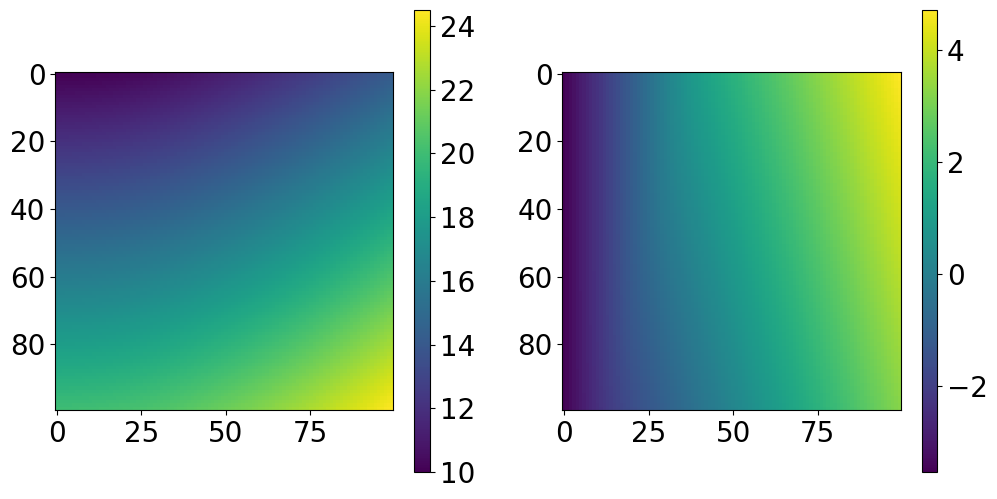

In [80]:
n = 100

B = 25
s = 0.01 #pc
Egamma1 = 100
Egamma2 = 125

ms = np.logspace(priors[name]['bounds_rounds'][0][-2][0][0],priors[name]['bounds_rounds'][0][-2][0][1],n)
gs = np.logspace(priors[name]['bounds_rounds'][0][-2][1][0],priors[name]['bounds_rounds'][0][-2][1][1],n)[::-1]
m, g = np.meshgrid(ms,gs)

ms = ms/1_000
Egamma1 = Egamma1/1000
Egamma2 = Egamma2/1000
B_GeV = B*1.95e-20
s = s*3.0857e+18/1.98e-14

Ecrit = (m**2)*(10/(B*g))
arg1 = s*g*1e-11*B_GeV*np.sqrt(1 + Ecrit/Egamma1)
arg2 = s*g*1e-11*B_GeV*np.sqrt(1 + Ecrit/Egamma2)

fig = plt.figure(figsize=(12, 6))
fig.add_subplot(1,2,1)
fig.add_subplot(1,2,2)
fig.axes[0].imshow(arg)
fig.axes[1].imshow(np.log10(abs(arg2-arg1)))
cbar0 = fig.colorbar(fig.axes[0].get_images()[0],ax=fig.axes[0], aspect=30)
cbar1 = fig.colorbar(fig.axes[1].get_images()[0],ax=fig.axes[1], aspect=30)

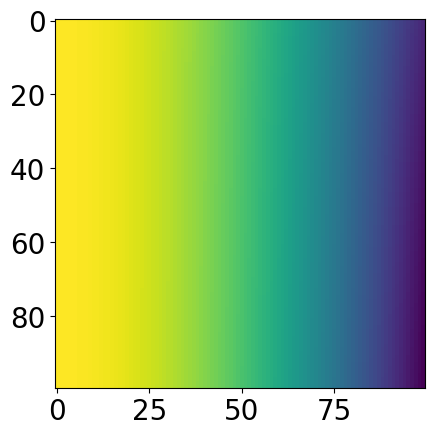

In [34]:
n = 100
ms = np.linspace(0,1,n)
gs = np.linspace(10,20,n)
m, g = np.meshgrid(ms,gs)

B = 1
Egamma1 = 1
Egamma2 = 2

Ecrit = (m**2)*(10/(B*g))
arg1 = g*B*np.sqrt(1 + Ecrit/Egamma1)
arg2 = g*B*np.sqrt(1 + Ecrit/Egamma2)

plt.imshow(arg2-arg1)

In [35]:
arg1

array([[10.        , 10.00051014, 10.0020404 , ..., 14.00001458,
        14.07089198, 14.14213562],
       [10.1010101 , 10.10152024, 10.1030505 , ..., 14.10675421,
        14.17780674, 14.24922826],
       [10.2020202 , 10.20253034, 10.20406061, ..., 14.21341009,
        14.28463556, 14.35623273],
       ...,
       [19.7979798 , 19.79848994, 19.8000203 , ..., 24.12512006,
        24.20661914, 24.28867642],
       [19.8989899 , 19.89950004, 19.9010304 , ..., 24.22810174,
        24.30966892, 24.39179571],
       [20.        , 20.00051015, 20.0020405 , ..., 24.33106689,
        24.41270165, 24.49489743]])

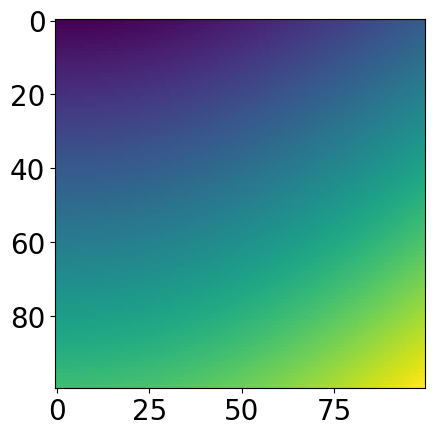

/home/gertwk/.conda/envs/swyft4-dev-notebook/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/gertwk/.conda/envs/swyft4-dev-notebook/lib/pyt ...
  rank_zero_warn(
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

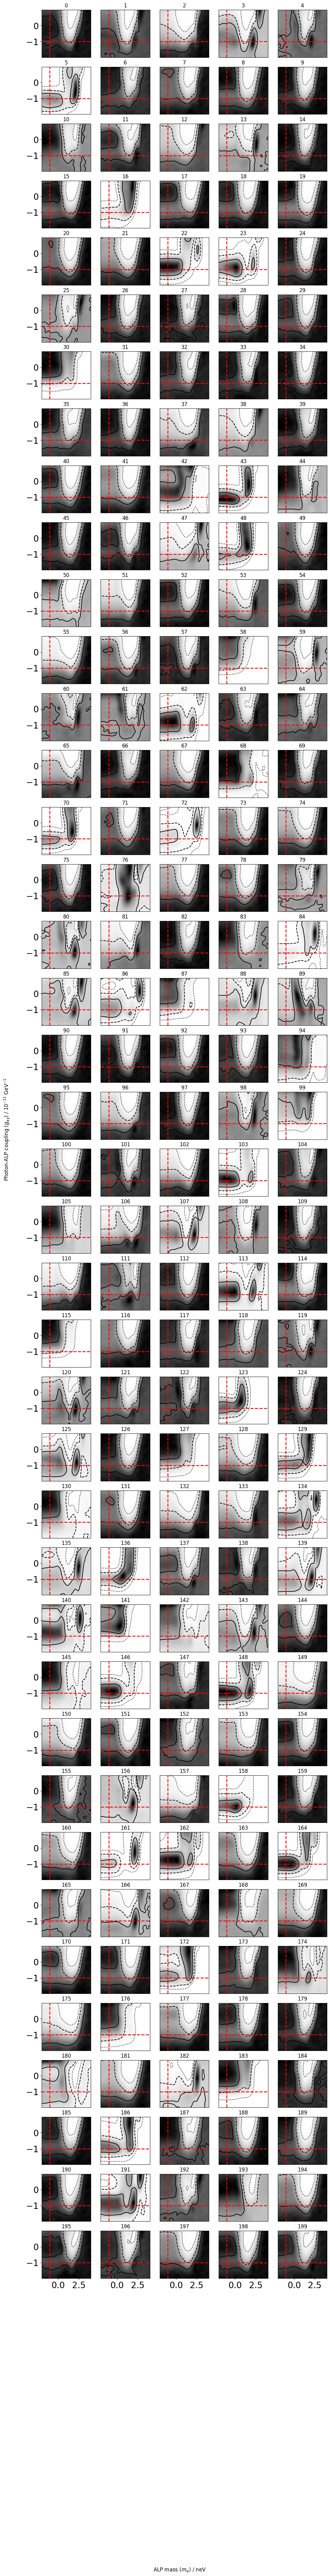

In [29]:
name = 'flare2_semi_informed'
n = 200
data = [priors[name]['samples_bad_params'][i] for i in range(n)]

dim = 5
fig = plt.figure(figsize=(12,(12/dim)*np.ceil(n/dim)))
for i in range(n): 
    fig.add_subplot(int(np.ceil(len(data)/dim)),dim,i+1)
    fig.axes[-1].set_title(str(i))
    if i < n-dim:
        fig.axes[-1].set_xticks([])
    # else:
    #     fig.axes[-1].set_xticks([ms[i-(len(gs)-1)*(dim)]])
    if i%dim != 0:
        fig.axes[-1].set_yticks([])
    # else:
    #     fig.axes[-1].set_yticks([gs[int(i/dim)]])
fig.supxlabel(xlabel)
fig.supylabel(ylabel)


logratios = prepare_logratios(name,data)
plot_posteriors(name, logratios, data, axes = fig.axes)

In [ ]:
dim = 3
prior_type = 'semi_informed'
names_selection = ['flare0_'+prior_type,'flare1_'+prior_type,'flare2_'+prior_type,'flare3_'+prior_type]
len_names = len(names_selection)
data = []
data_temp = []
logratios = []
logratios_temp = []

ds = [0,2,3]

for i, d in enumerate(ds):
    for name in names_selection:
        data_temp.append(copy.copy(priors[name]['samples_bad_params'][d]))
        logratios_temp.extend(prepare_logratios(name,data_temp[-1:]))

data = data_temp
logratios = logratios_temp

In [ ]:
colors_data=['r']*len(data)
for i in range(len(colors_data)):
    if i%len_names == 0: 
        colors_data[i] = 'k'
    elif i%len_names == 1: 
        colors_data[i] = 'b'
    elif i%len_names == 2:
        colors_data[i] = 'g'
    elif i%len_names == 3:
        colors_data[i] = 'r'
linestyles_data=['-']*len(data)
for i in range(len(colors_data)):
    if i%len_names == 0: 
        linestyles_data[i] = '-'
    elif i%len_names == 1: 
        linestyles_data[i] = '--'
    elif i%len_names == 2:
        linestyles_data[i] = '-.'
    elif i%len_names == 3:
        linestyles_data[i] = ':'

axis_ticksize=10
fig = plt.figure(figsize=(8,(8/len(names_selection))*np.ceil(len(data)/len(names_selection))))
noise_realization = 0
for i in range(len(data)): 
    fig.add_subplot(int(np.ceil(len(data)/len(names_selection))),len(names_selection),i+1)
    # fig.axes[-1].set_title(str(i))
    if i < len(data)-len_names:
        fig.axes[i].set_xticks([])
    else:
        fig.axes[i].set_xticks([-2,0,2,4])
        fig.axes[i].set_xticklabels(['','$10^{0}$','$10^{2}$','$10^{4}$'],rotation=45,fontsize=axis_ticksize)
    if i%len_names != 0:
        fig.axes[i].set_yticks([])
    else:
        fig.axes[i].set_yticks([-2,-1,0,1])
        fig.axes[i].set_yticklabels(['','$10^{-1}$','$10^{0}$','$10^{1}$'],fontsize=axis_ticksize)
    if i%len_names == len_names-1:
        noise_realization +=1
        fig.axes[i].set_ylabel('Noise Realization '+str(noise_realization), labelpad = 14)
        fig.axes[i].yaxis.set_label_position('right')
        
fig.supxlabel(xlabel)
fig.supylabel(ylabel)


plot_posteriors(name, logratios, data, axes = fig.axes, colors_truth = colors_data, linestyles_truth=linestyles_data)

for i in range(len(data)): 
    name = names_selection[i%len(names_selection)]
    fig.axes[i].set_xlim(priors[name]['bounds_rounds'][0][0][0])
    fig.axes[i].set_ylim(priors[name]['bounds_rounds'][0][0][1])
    if i < len_names:
        fig.axes[i].set_title(ALP_titles[name.split('_')[0]], pad = 14, fontsize = 10)




# fig_specs.supylabel('Residuals of log of Counts', fontsize=18)
# fig_specs.tight_layout()

In [ ]:
POI1 = 2
POI2 = 3
fig = plt.figure(figsize=(8,(8/len_names)*np.ceil(len(data)/len_names)))
for i in range(len(data)):
    name = names_selection[i%len(names_selection)]
    fig.add_subplot(int(np.ceil(len(data)/len_names)),len_names,i+1)


fig.supxlabel("Spectral Amplitude ($\Phi$) / $10^{-9} \mathrm{\ TeV^{-1} \ cm^{-2} \ s^{-1}}$")
fig.supylabel("Spectral Index ($\Gamma$)")

plot_posteriors(name, logratios, data, axes = fig.axes, POIs=[POI1,POI2], colors_truth = colors_data, linestyles_truth=linestyles_data)

noise_realization = 0
for i in range(len(data)):
    name = names_selection[i%len(names_selection)]
    bounds1 = np.round(np.array(priors[name]['bounds_rounds'][0][-2][POI1]),decimals=2)
    bounds2 = np.round(np.array(priors[name]['bounds_rounds'][0][-2][POI2]),decimals=2)
    if i < len_names:
        fig.axes[i].set_title(ALP_titles[name.split('_')[0]], pad = 14, fontsize = 10)
    if i < len(data)-len_names:
        fig.axes[i].set_xticks([])
    else:
        fig.axes[i].set_xticks([bounds1[0],data[i]['params'][2],bounds1[1]],fontsize = axis_ticksize)
        fig.axes[i].set_xticklabels(np.round(10**fig.axes[i].get_xticks()/(10**-9),decimals=2),rotation=45,fontsize=axis_ticksize)
    if i%len_names == len_names-1:
        noise_realization +=1
        fig.axes[i].set_ylabel('Noise Realization '+str(noise_realization), labelpad = 14)
        fig.axes[i].yaxis.set_label_position('right')
    fig.axes[i].set_yticks([bounds2[0],data[i]['params'][POI2],bounds2[1]],fontsize = axis_ticksize)
    fig.axes[i].set_yticklabels(np.round(fig.axes[i].get_yticks(),decimals=2),fontsize=axis_ticksize)        
    fig.axes[i].set_xlim(bounds1*(1 + np.array([0.0,-0.0])))
    fig.axes[i].set_ylim(bounds2*(1 + np.array([0.0,-0.0])))
fig.tight_layout()

In [ ]:
POI1 = 2
POI2 = 4
fig = plt.figure(figsize=(8,(8/len_names)*np.ceil(len(data)/len_names)))
for i in range(len(data)):
    name = names_selection[i%len(names_selection)]
    fig.add_subplot(int(np.ceil(len(data)/len_names)),len_names,i+1)


fig.supxlabel("Spectral Amplitude ($\Phi$) / $10^{-9} \mathrm{\ TeV^{-1} \ cm^{-2} \ s^{-1}}$")
fig.supylabel("Cut-Off Energy ($E_{cut}$) / GeV")

plot_posteriors(name, logratios, data, axes = fig.axes, POIs=[POI1,POI2], colors_truth = colors_data, linestyles_truth=linestyles_data)

noise_realization = 0
for i in range(len(data)):
    name = names_selection[i%len(names_selection)]
    bounds1 = np.round(np.array(priors[name]['bounds_rounds'][0][-2][POI1]),decimals=2)
    bounds2 = np.round(np.array(priors[name]['bounds_rounds'][0][-2][POI2]),decimals=2)
    if i < len_names:
        fig.axes[i].set_title(ALP_titles[name.split('_')[0]], pad = 14, fontsize = 10)
    if i < len(data)-len_names:
        fig.axes[i].set_xticks([])
    else:
        fig.axes[i].set_xticks([bounds1[0],data[i]['params'][2],bounds1[1]],fontsize = axis_ticksize)
        fig.axes[i].set_xticklabels(np.round(10**fig.axes[i].get_xticks()/(10**-9),decimals=2),rotation=45,fontsize=axis_ticksize)
    if i%len_names == len_names-1:
        noise_realization +=1
        fig.axes[i].set_ylabel('Noise Realization '+str(noise_realization), labelpad = 14)
        fig.axes[i].yaxis.set_label_position('right')
    fig.axes[i].set_yticks([bounds2[0],data[i]['params'][POI2],bounds2[1]],fontsize = axis_ticksize)
    fig.axes[i].set_yticklabels(np.round(10**fig.axes[i].get_yticks(),decimals=0).astype(int),fontsize=axis_ticksize)        
    fig.axes[i].set_xlim(bounds1*(1 + np.array([0.0,-0.0])))
    fig.axes[i].set_ylim(bounds2*(1 + np.array([0.0,-0.0])))
fig.tight_layout()

In [ ]:
POI1 = 3
POI2 = 4
fig = plt.figure(figsize=(8,(8/len_names)*np.ceil(len(data)/len_names)))
for i in range(len(data)):
    name = names_selection[i%len(names_selection)]
    fig.add_subplot(int(np.ceil(len(data)/len_names)),len_names,i+1)


fig.supxlabel("Spectral Index ($\Gamma$)")
fig.supylabel("Cut-Off Energy ($E_{cut}$) / GeV")

plot_posteriors(name, logratios, data, axes = fig.axes, POIs=[POI1,POI2], colors_truth = colors_data, linestyles_truth=linestyles_data)

noise_realization = 0
for i in range(len(data)):
    name = names_selection[i%len(names_selection)]
    bounds1 = np.round(np.array(priors[name]['bounds_rounds'][0][-2][POI1]),decimals=2)
    bounds2 = np.round(np.array(priors[name]['bounds_rounds'][0][-2][POI2]),decimals=2)
    if i < len_names:
        fig.axes[i].set_title(ALP_titles[name.split('_')[0]], pad = 14, fontsize = 10)
    if i < len(data)-len_names:
        fig.axes[i].set_xticks([])
    else:
        fig.axes[i].set_xticks([bounds1[0],data[i]['params'][POI2],bounds1[1]],fontsize = axis_ticksize)
        fig.axes[i].set_xticklabels(np.round(fig.axes[i].get_xticks(),decimals=2),fontsize=axis_ticksize)
    if i%len_names == len_names-1:
        noise_realization +=1
        fig.axes[i].set_ylabel('Noise Realization '+str(noise_realization), labelpad = 14)
        fig.axes[i].yaxis.set_label_position('right')
    fig.axes[i].set_yticks([bounds2[0],data[i]['params'][POI2],bounds2[1]],fontsize = axis_ticksize)
    fig.axes[i].set_yticklabels(np.round(10**fig.axes[i].get_yticks(),decimals=0).astype(int),fontsize=axis_ticksize)        
    fig.axes[i].set_xlim(bounds1*(1 + np.array([0.0,-0.0])))
    fig.axes[i].set_ylim(bounds2*(1 + np.array([0.0,-0.0])))
fig.tight_layout()

In [ ]:
fig_specs = plt.figure(figsize=(12,4))
A = priors[name]['A']
fig_specs.add_subplot(1,1,1)
A.configure_plot(xmin=2e1, xmax=6e3, ymin=None,ymax=None,legend=1, logx=1, logy=0)
for i in range(len_names):
    A.configure_model(params=data[i]['params'])
    A.import_counts(obs=data[i]['data'],exp=data[i]['exp'])
    new_fig = 1 if i==0 else 0
    A.compute_case(new_fig=new_fig,new_counts=0,color=colors_data[i],color_obs=colors_data[i],linestyle_obs=linestyles_data[i], 
                   linestyle=linestyles_data[i],axes=fig_specs.axes[-1],
                   label_exp=ALP_titles[names_selection[i].split('_')[0]],label_obs=False, errorbands=1, errors=False, plot_exp=1, plot_obs=0, transparency=0)
fig_specs.axes[-1].set_title('Expected Spectra for Representative Physics Assumptions')
# fig_specs.axes[-1].set_xlabel('')
# fig_specs.axes[-1].set_xticks([])
# fig_specs.axes[-1].set_ylabel('')